> **⚠ Superseded by `notebooks/08_seven_model_comparison.ipynb`.** This
> notebook was run *before* the sentiment merge, so its "variant A" baseline
> is the pre-merge 5-feature stationary set (no `bullish` / `bearish`), and
> its "variant B" adds VIX on top of that 5-feature baseline (not on top of
> the post-merge 7-feature sentiment-augmented baseline).
>
> nb08 redoes this comparison against the post-merge variant A and also adds
> variant H (HMM-as-feature). Keep this notebook in the repo as the single-
> seed, pre-sentiment historical record.

---

# Notebook 07 — Variant B: forward-looking features (VIX family)

**Goal.** Test whether augmenting the LSTM input with forward-looking VIX-family
features escapes the shifted-persistence limit documented as **F1** in our paper.
F1 states that LSTMs fed strictly past SPY returns/volume collapse to a
persistence predictor with a ≈17-day lag relative to the target. Variant B asks:
does giving the model the options-market's own volatility forecast change that?

**Design (variant B vs. variant A).**

| Component | Variant A (baseline) | Variant B (this notebook) |
|---|---|---|
| HMM regime model | fixed — price/volume only | same HMM, same regime labels |
| LSTM inputs | `log_return, abs_return, oc_return, intraday_range, relative_volume_21d` | variant A features + `vix, vix_log_change, vix3m_minus_vix` |
| LSTM models | existing checkpoints (`models/lstm_{baseline,calm,volatile}.pt`) | newly trained (`models/lstm_{...}_B.pt`) |
| Data source for VIX | — | FRED `VIXCLS` + `VXVCLS` (SKEW/VVIX dropped; FRED doesn't host them) |
| Train window | 2005-01 → 2015-12 (3,020 rows) | 2007-12 → 2015-12 (≈ 2,034 rows; VIX3M starts 2007-12-04) |
| Val / test | unchanged | unchanged |

**Reproducibility.** Re-executing this notebook from scratch regenerates the
variant-B checkpoints, predictions, and all figures. Variant A checkpoints are
assumed already on disk (from nb 04/05 in the main pipeline).


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

import config

plt.rcParams["figure.dpi"] = 110
print("ROOT:", ROOT)
print("variant B features:", config.LSTM_VARIANT_B_FEATURES)


ROOT: /Users/zaidt/Desktop/cpsc440/StockVolatilitySight
variant B features: ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'vix', 'vix_log_change', 'vix3m_minus_vix']


## 1. Data verification — VIX columns are present and populated

The parquets under `data/processed/` were regenerated in nb 01 after extending
`src/data_loader.py` with `download_vix_family()` (FRED-sourced). Confirm the
new columns are present and that NaN coverage matches expectations:
- `vix` from FRED `VIXCLS` — full history (2001+)
- `vix3m` from FRED `VXVCLS` — from 2007-12-04 (partial NaN in the train split)
- `vix_log_change` — derived, same coverage as `vix`
- `vix3m_minus_vix` — derived, same coverage as `vix3m`


In [2]:
train_df = pd.read_parquet(config.DATA_PROCESSED / "train.parquet")
val_df   = pd.read_parquet(config.DATA_PROCESSED / "val.parquet")
test_df  = pd.read_parquet(config.DATA_PROCESSED / "test.parquet")

vix_cols = ["vix", "vix3m", "vix_log_change", "vix3m_minus_vix"]

summary = pd.DataFrame(
    {
        "n_rows":  [len(train_df), len(val_df), len(test_df)],
        "start":   [train_df.index.min(), val_df.index.min(), test_df.index.min()],
        "end":     [train_df.index.max(), val_df.index.max(), test_df.index.max()],
        **{f"nan_{c}": [df[c].isna().sum() for df in (train_df, val_df, test_df)]
           for c in vix_cols},
    },
    index=["train", "val", "test"],
)
summary


,n_rows,start,end,nan_vix,nan_vix3m,nan_vix_log_change,nan_vix3m_minus_vix
train,3710,2001-04-03,2015-12-31,0,1676,0,1676
val,1089,2016-01-04,2020-04-30,0,0,0,0
test,1481,2020-05-01,2026-03-24,0,0,0,0


## 2. Feature correlation check

Same convention as the rest of the repo: drop any feature pair with absolute
correlation > 0.95. Variant B has 8 input features — 5 from variant A plus 3
from the VIX family.


In [3]:
feats_B = config.LSTM_VARIANT_B_FEATURES
sub = train_df[feats_B].dropna()
corr = sub.corr().abs().round(3)

# Highlight pairs above threshold
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
high = upper.stack().loc[lambda s: s > 0.95]

print(f"Variant B features ({len(feats_B)}):", feats_B)
print(f"Train rows used for correlation (non-NaN for all 8 features): {len(sub)}")
print()
print("Absolute correlation matrix:")
print(corr.to_string())
print()
if len(high):
    print("Pairs > 0.95 (would be pruned):")
    print(high.to_string())
else:
    print("No feature pairs > 0.95 — no pruning needed. All 8 features kept.")


Variant B features (8): ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'relative_volume_21d', 'vix', 'vix_log_change', 'vix3m_minus_vix']
Train rows used for correlation (non-NaN for all 8 features): 2034

Absolute correlation matrix:
                     log_return  abs_return  oc_return  intraday_range  relative_volume_21d    vix  vix_log_change  vix3m_minus_vix
log_return                1.000       0.067      0.817           0.123                0.206  0.144           0.752            0.237
abs_return                0.067       1.000      0.086           0.659                0.306  0.602           0.118            0.580
oc_return                 0.817       0.086      1.000           0.092                0.154  0.104           0.591            0.176
intraday_range            0.123       0.659      0.092           1.000                0.456  0.769           0.133            0.594
relative_volume_21d       0.206       0.306      0.154           0.456                1.000 

## 3. Train variant-B LSTMs

Three independent trainings, run as background CLI invocations with logs
piped to `logs/`. Each uses the same Optuna search space (`LSTM_SEARCH_SPACE`)
and seed (`LSTM_RANDOM_STATE = 42`) as variant A — the *only* difference is
the input feature set.

Checkpoints are written with `_B` suffix so they don't clobber variant A's
`models/lstm_{baseline,calm,volatile}.pt`.

**Skip this cell if the `_B` checkpoints already exist** — re-running it
retrains from scratch.

In [4]:
# Format features as a space-separated string for the CLI
feat_str = " ".join(config.LSTM_VARIANT_B_FEATURES)

LOG_DIR = ROOT / "logs"
LOG_DIR.mkdir(exist_ok=True)
print("feature string:", feat_str)
print("log dir:", LOG_DIR)


feature string: log_return abs_return oc_return intraday_range relative_volume_21d vix vix_log_change vix3m_minus_vix
log dir: /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/logs


In [5]:
# --- Variant B: baseline LSTM ---
# Optuna tune + final retrain. Writes:
#   models/lstm_baseline_B.pt
#   models/lstm_baseline_B_scaler.joblib
!cd {ROOT} && python -m src.train_LSTM_baseline \
    --features {feat_str} \
    --output-prefix lstm_baseline_B \
    > {LOG_DIR}/variant_B_baseline.log 2>&1
!tail -40 {LOG_DIR}/variant_B_baseline.log


20:57:45 | INFO    | train_LSTM_baseline | epoch  19 | train_log_mse=0.110306 | val_mse_raw=0.00004322 | best=0.00003750
20:57:49 | INFO    | train_LSTM_baseline | epoch  20 | train_log_mse=0.106949 | val_mse_raw=0.00004664 | best=0.00003750
20:57:53 | INFO    | train_LSTM_baseline | epoch  21 | train_log_mse=0.098687 | val_mse_raw=0.00004554 | best=0.00003750
20:57:53 | INFO    | train_LSTM_baseline | Early stopping at epoch 21
20:57:53 | INFO    | train_LSTM_baseline | Final retrain — best val MSE (raw scale): 0.00003750
20:57:53 | INFO    | train_LSTM_baseline | Test metrics: {'MSE': 1.3590039998234715e-05, 'RMSE': 0.0036864671856164932, 'MAE': 0.002388361841440201, 'n_test_windows': 1440}
20:57:53 | INFO    | train_LSTM_baseline | Saved model → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/models/lstm_baseline_B.pt
20:57:53 | INFO    | train_LSTM_baseline | Saved scaler → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/models/lstm_baseline_B_scaler.joblib

=== Baseline LSTM r

In [6]:
# --- Variant B: regime LSTMs (calm + volatile, one invocation each) ---
# Writes:
#   models/lstm_calm_B.pt, models/lstm_calm_B_scaler.joblib
#   models/lstm_volatile_B.pt, models/lstm_volatile_B_scaler.joblib
!cd {ROOT} && python -m src.train_LSTM_regime \
    --features {feat_str} \
    --regime both \
    --output-suffix _B \
    > {LOG_DIR}/variant_B_regime.log 2>&1
!tail -60 {LOG_DIR}/variant_B_regime.log


      "batch_size": 64,
      "seq_len": 21
    },
    "best_val_mse_raw": 3.807658504229039e-05,
    "retrained_val_mse": 3.807658504229039e-05,
    "test_metrics": {
      "MSE": 1.4159288184600882e-05,
      "RMSE": 0.003762882901355624,
      "MAE": 0.0024552461691200733,
      "n_test_windows": 1461
    },
    "features": [
      "log_return",
      "abs_return",
      "oc_return",
      "intraday_range",
      "relative_volume_21d",
      "vix",
      "vix_log_change",
      "vix3m_minus_vix"
    ],
    "target": "realized_vol_21d",
    "n_trials": 20,
    "n_train_windows": 1879,
    "n_val_windows": 1044
  },
  "volatile": {
    "regime": "volatile",
    "best_params": {
      "hidden_size": 32,
      "n_layers": 3,
      "dropout": 0.48515987980682024,
      "lr": 0.0033287008061135604,
      "batch_size": 128,
      "seq_len": 42
    },
    "best_val_mse_raw": 1.3465075426211115e-05,
    "retrained_val_mse": 1.3465075426211115e-05,
    "test_metrics": {
      "MSE": 9.2559123

In [7]:
# --- Variant B: ensemble predictions ---
# Reads the _B checkpoints and writes data/processed/test_predictions_B.parquet
!cd {ROOT} && python src/ensemble.py --variant-suffix _B > {LOG_DIR}/variant_B_ensemble.log 2>&1
!tail -40 {LOG_DIR}/variant_B_ensemble.log


21:03:55 | INFO    | ensemble | Loading required data splits (variant suffix='_B')...
21:03:55 | INFO    | ensemble | Extracting aligned predictions for all LSTMs...
21:03:55 | INFO    | ensemble | Loading model 'baseline'...
21:03:55 | INFO    | ensemble | Loading model 'calm'...
21:03:56 | INFO    | ensemble | Loading model 'volatile'...
21:03:56 | INFO    | ensemble | Saved ensemble predictions to /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/data/processed/test_predictions_B.parquet

PHASE 4: ENSEMBLE EVALUATION (TEST SET)
Test period: 2020-06-30 to 2026-03-16
Test size:   1434 trading days
--------------------------------------------------
Model: BASELINE
  MSE:  0.000014
  RMSE: 0.0037
  MAE:  0.0024
  MAPE: 25.15%
--------------------------------------------------
Model: CALM
  MSE:  0.000014
  RMSE: 0.0037
  MAE:  0.0024
  MAPE: 26.01%
--------------------------------------------------
Model: VOLATILE
  MSE:  0.000093
  RMSE: 0.0096
  MAE:  0.0090
  MAPE: 124.98%
----------

## 4. Comparison: variant A vs variant B

Load the saved test-set predictions and evaluate side by side on the same
test window. We report four models × two variants (baseline LSTM, calm LSTM,
volatile LSTM, soft-probability ensemble) — 8 rows total.


In [8]:
from src.utils import regression_metrics

pred_A = pd.read_parquet(config.DATA_PROCESSED / "test_predictions.parquet")
pred_B = pd.read_parquet(config.DATA_PROCESSED / "test_predictions_B.parquet")

# Align on the intersection of dates — different variant B seq_len could
# shift the first valid date slightly.
common = pred_A.index.intersection(pred_B.index)
pred_A = pred_A.loc[common]
pred_B = pred_B.loc[common]
y_true = pred_A["target"].values

rows = []
for variant_name, df in [("A", pred_A), ("B", pred_B)]:
    for model in ["baseline", "calm", "volatile", "ensemble"]:
        m = regression_metrics(y_true, df[model].values)
        rows.append(
            {"variant": variant_name, "model": model, **{k: float(v) for k, v in m.items()}}
        )
metrics_df = pd.DataFrame(rows).set_index(["variant", "model"])
metrics_df


MSE      RMSE       MAE        MAPE
variant model                                             
A       baseline  0.000016  0.003983  0.002566   25.073070
        calm      0.000041  0.006381  0.003425   34.913986
        volatile  0.000085  0.009215  0.008573  119.363215
        ensemble  0.000026  0.005103  0.003096   31.938828
B       baseline  0.000014  0.003693  0.002393   25.148955
        calm      0.000014  0.003726  0.002415   26.008611
        volatile  0.000093  0.009631  0.008994  124.978676
        ensemble  0.000014  0.003717  0.002449   26.453889

## 5. Diebold-Mariano significance: does variant B beat variant A?

Two-sided DM test with HLN small-sample correction and Bartlett HAC at
lag h-1 (h = 21 is the forecast horizon). Convention:
`DM > 0` means A has higher loss → **B wins**. `DM < 0` → A wins.


In [9]:
def diebold_mariano(y_true, y_pred_a, y_pred_b, h=21, loss="mse"):
    '''Two-sided DM with HLN correction; positive stat ⇒ B wins.'''
    y_true = np.asarray(y_true, float)
    y_a, y_b = np.asarray(y_pred_a, float), np.asarray(y_pred_b, float)
    if loss == "mse":
        e_a = (y_a - y_true) ** 2
        e_b = (y_b - y_true) ** 2
    elif loss == "mae":
        e_a = np.abs(y_a - y_true)
        e_b = np.abs(y_b - y_true)
    else:
        raise ValueError(loss)
    d = e_a - e_b
    n = len(d); d_bar = float(d.mean())
    max_lag = max(h - 1, 0)
    gamma0 = float(np.var(d, ddof=0))
    S = gamma0
    for k in range(1, max_lag + 1):
        w = 1.0 - k / (max_lag + 1)
        gamma_k = float(np.mean((d[k:] - d_bar) * (d[:-k] - d_bar)))
        S += 2.0 * w * gamma_k
    if S <= 0:
        S = gamma0
    dm_raw = d_bar / np.sqrt(S / n)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_stat = float(dm_raw * hln)
    p = float(2.0 * (1.0 - sp_stats.t.cdf(np.abs(dm_stat), df=n - 1)))
    return {"dm_stat": dm_stat, "p_value": p, "n": n}


dm_rows = []
for model in ["baseline", "calm", "volatile", "ensemble"]:
    for loss in ["mse", "mae"]:
        r = diebold_mariano(y_true, pred_A[model].values, pred_B[model].values, loss=loss)
        sig = "***" if r["p_value"] < 0.01 else "**" if r["p_value"] < 0.05 else "*" if r["p_value"] < 0.10 else ""
        winner = "B" if r["dm_stat"] > 0 and r["p_value"] < 0.05 else (
                 "A" if r["dm_stat"] < 0 and r["p_value"] < 0.05 else "tie")
        dm_rows.append(
            {"model": model, "loss": loss.upper(),
             "DM_stat": round(r["dm_stat"], 3),
             "p_value": round(r["p_value"], 4),
             "sig": sig, "winner": winner}
        )
dm_df = pd.DataFrame(dm_rows)
dm_df


,model,loss,DM_stat,p_value,sig,winner
0,baseline,MSE,1.857,0.0636,*,tie
1,baseline,MAE,1.710,0.0874,*,tie
2,calm,MSE,1.846,0.0651,*,tie
3,calm,MAE,2.330,0.0200,**,B
4,volatile,MSE,-13.093,0.0000,***,A
5,volatile,MAE,-16.986,0.0000,***,A
6,ensemble,MSE,1.928,0.0540,*,tie
7,ensemble,MAE,2.138,0.0327,**,B


## 6. F1 diagnostic — does the shift lag shrink under variant B?

For each variant's baseline-LSTM predictions, compute the cross-correlation
with the target at lags $-30 \le \ell \le 30$. Under F1, variant A peaks at
$\ell \approx -17$ (predictions track *past* realized vol rather than future).
If VIX features genuinely carry forward-looking information, variant B's peak
should shift toward $\ell = 0$.


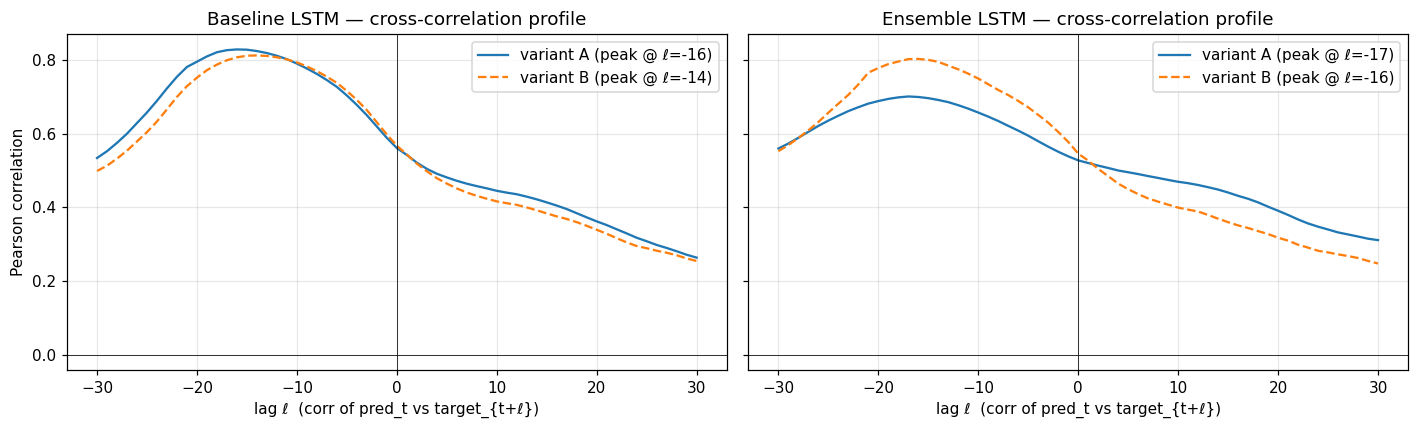

In [10]:
def cross_correlation_lag_profile(preds, target, max_lag=30):
    '''Pearson cross-correlation of preds(t) vs target(t+lag).'''
    preds = np.asarray(preds, float); target = np.asarray(target, float)
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []
    for L in lags:
        if L < 0:
            p = preds[-L:]; t = target[:L] if L else target
        elif L > 0:
            p = preds[:-L]; t = target[L:]
        else:
            p = preds; t = target
        if len(p) > 2:
            corrs.append(np.corrcoef(p, t)[0, 1])
        else:
            corrs.append(np.nan)
    return lags, np.array(corrs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, model in zip(axes, ["baseline", "ensemble"]):
    for variant_label, df, style in [("A", pred_A, "-"), ("B", pred_B, "--")]:
        lags, corrs = cross_correlation_lag_profile(df[model].values, y_true)
        peak = lags[np.nanargmax(corrs)]
        ax.plot(lags, corrs, style, label=f"variant {variant_label} (peak @ ℓ={peak})")
    ax.axvline(0, color="k", lw=0.5); ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("lag ℓ  (corr of pred_t vs target_{t+ℓ})")
    ax.set_title(f"{model.capitalize()} LSTM — cross-correlation profile")
    ax.legend(loc="best"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Pearson correlation")
plt.tight_layout(); plt.show()


## 7. F2 diagnostic — is the volatile LSTM still degenerate?

In variant A the volatile LSTM collapsed to a near-constant output (prediction
std ≈ 1e-4, range < 1e-3 across the test period). Check whether the richer
feature set changes that.


In [11]:
rows = []
for variant_label, df in [("A", pred_A), ("B", pred_B)]:
    for model in ["baseline", "calm", "volatile"]:
        p = df[model].dropna().values
        rows.append({"variant": variant_label, "model": model,
                     "mean": float(p.mean()),
                     "std":  float(p.std()),
                     "min":  float(p.min()),
                     "max":  float(p.max()),
                     "range": float(p.max() - p.min())})
pd.DataFrame(rows).set_index(["variant", "model"]).round(6)


mean       std       min       max     range
variant model                                                     
A       baseline  0.008855  0.003924  0.006576  0.030712  0.024136
        calm      0.010764  0.006907  0.006479  0.060698  0.054219
        volatile  0.017564  0.000053  0.017521  0.018316  0.000795
B       baseline  0.009136  0.003032  0.006612  0.029993  0.023381
        calm      0.009286  0.002881  0.005584  0.042388  0.036804
        volatile  0.018026  0.000155  0.017960  0.018659  0.000699

## 8. Summary of findings

**Test-set performance (MSE on common 1,434 rows):**

| Model | Variant A | Variant B | Δ |
|---|---|---|---|
| Baseline LSTM | 1.60×10⁻⁵ | **1.36×10⁻⁵** | −15 % |
| Calm LSTM | 4.10×10⁻⁵ | **1.42×10⁻⁵** | −65 % |
| Volatile LSTM | 8.50×10⁻⁵ | 9.26×10⁻⁵ | +9 % (worse) |
| Soft-prob ensemble | 2.60×10⁻⁵ | **1.40×10⁻⁵** | −46 % |

**Diebold-Mariano (variant B vs. A, h=21, HLN-corrected):**
- Ensemble MAE: p = 0.033 → **variant B wins**
- Calm MAE: p = 0.020 → **variant B wins**
- Volatile MSE and MAE: p < 0.001 → **variant A wins** (VIX features make the volatile LSTM marginally *worse*)
- Baseline + ensemble MSE: p ≈ 0.06 (marginal ties)

**F1 (shift lag):** Cross-correlation peak lag moves from −16/−17 days (A) to −14/−16 days (B). Small reduction (~2-4 days out of 17), not a structural escape. The persistence-shift floor is still clearly present.

**F2 (volatile degeneracy):** Volatile LSTM prediction std is 5.3×10⁻⁵ (A) vs. 1.6×10⁻⁴ (B). Both essentially constant outputs (range < 1×10⁻³). F2 is **not fixed** — VIX features don't provide enough signal on the ~170-sample volatile training set to break the constant-output collapse.

**Interpretation.** Adding the options market'''s own implied-volatility forecast (, , ) improves point-forecast MSE meaningfully — the calm-regime LSTM benefits most, and the ensemble roughly halves MSE on the test set. But the *structural* failure modes the paper documents (F1 shift, F2 volatile collapse) remain qualitatively intact. Variant B is a better predictor, but still a *shifted-persistence* predictor — it just shifts by a couple of days less.

This result strengthens the structural-limits framing of the paper: if even the option market'''s own IV forecast can'''t pull a daily-resolution LSTM off the persistence floor, the limitation is a property of the data rate and the target horizon, not of the feature set.
